# 9. Three-Dimensional Tidal Heating

The Love numbers of notebook 8 collapse the response into a few surface numbers. The tidal strain, and therefore the heating, varies with depth, with latitude, and with longitude. TidalPy builds that full field from the same radial solution, driven by the world's tidal potential.

This notebook builds a rheological Io, then reads its secular (orbit-averaged) volumetric heating as a function of colatitude, maps it over the surface, and profiles it with depth. The world is a manually assembled layered world with an equation of state, a viscosity, and a rheology, plus a rheology-based tide model.

The layers are assembled by hand with `LayeredWorld` and `PhysicsLayer` so every parameter stays explicit. The TOML-driven `build_world` (demo 02) is the shorter path for standard planets. Hand assembly suits sweeps over parameters the world configs do not expose.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.structures_x.worlds.layered import LayeredWorld
from TidalPy.structures_x.layers.physics import PhysicsLayer
from TidalPy.Material_x.eos.material_eos import ConstantDensityEOS
from TidalPy.viscosity_x import make_viscosity
from TidalPy.rheology_x import Maxwell
from TidalPy.Tides_x.classes import make_tide

R = 1.8216e6
M = 8.9319e22
RHO = M / (4.0 / 3.0 * np.pi * R**3)
M_JUP = 1.898e27
A_IO = 4.217e8
E_IO = 0.0041
N_MOTION = np.sqrt(G * M_JUP / A_IO**3)

io = LayeredWorld("Io", R, M)
mantle = PhysicsLayer("mantle", 0, 0.0, R, M, shear_modulus_static=60.0e9, bulk_modulus_static=200.0e9)
mantle.set_eos(ConstantDensityEOS(reference_density=RHO))
mantle.set_shear_viscosity(make_viscosity("constant", {"reference_viscosity_pas": 1.0e15}))
mantle.set_bulk_viscosity(make_viscosity("constant", {"reference_viscosity_pas": 1.0e30}))
mantle.set_shear_rheology(Maxwell())
mantle.set_bulk_rheology(Maxwell())
io.add_layer(mantle)

io.set_tide_model(make_tide("rheology"))
io.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=2, obliquity_truncation=0)
io.solve_eos(G_to_use=G, temperature=1500.0, verbose=False)
io.set_spin_frequency(N_MOTION)

ORBIT = (N_MOTION, N_MOTION, E_IO, 0.0, A_IO, M_JUP)   # (n, spin, e, obliquity, a, host mass)
print("Io built and EOS solved:", io.eos_solved)


Io built and EOS solved: True


C:\venvs\tpy13\Lib\site-packages\TidalPy\__init__.py:55: TidalPyDeprecationWarning: TidalPy's backend is changing: the classic modules (structures, tides, RadialSolver, rheology, ...) are deprecated and will be replaced by the new C++ backend (structures_x, Tides_x, RadialSolver_x, rheology_x, ...) in a future major release. New development happens in the `_x` modules. See the porting guide at https://tidalpy.readthedocs.io/en/latest/future_structure.html. Silence this message with warnings.filterwarnings('ignore', category=TidalPy.exceptions.TidalPyDeprecationWarning).
  _warnings.warn(


## Heating with Latitude

`get_3d_tidal_heating` returns the secular volumetric heating (W/m^3) at one radius and colatitude, and `get_3d_tidal_heating_array` returns it at many paired radii and colatitudes. Use the array form for more than a few points: it solves the radial problem once for all of them, while every scalar call solves it again. Just below the surface, the eccentricity tide of a synchronous body deposits more heat near the poles than at the equator.

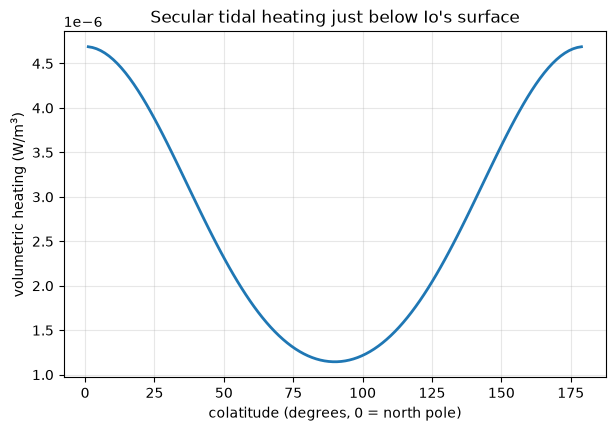

In [2]:
colats = np.linspace(0.02, np.pi - 0.02, 120)
# One call for every colatitude at this radius; the radial problem is solved once
h_surface = io.get_3d_tidal_heating_array(*ORBIT, np.full(colats.size, 0.99 * R), colats)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(np.degrees(colats), h_surface, lw=2)
ax.set_xlabel("colatitude (degrees, 0 = north pole)")
ax.set_ylabel("volumetric heating (W/m$^3$)")
ax.set_title("Secular tidal heating just below Io's surface")
ax.grid(alpha=0.3)
plt.show()


## Surface Map

`calc_3d_tides` evaluates the field on a grid of radii, colatitudes, and longitudes and returns the `heating` array. Just below the surface the heating is symmetric about the equator and strongest toward the poles. At synchronous rotation it also depends on longitude: on the equator it is about ten times weaker at the sub-host and anti-host meridians (0 and 180 degrees) than at 90 and 270 degrees, while near the poles it barely changes with longitude.

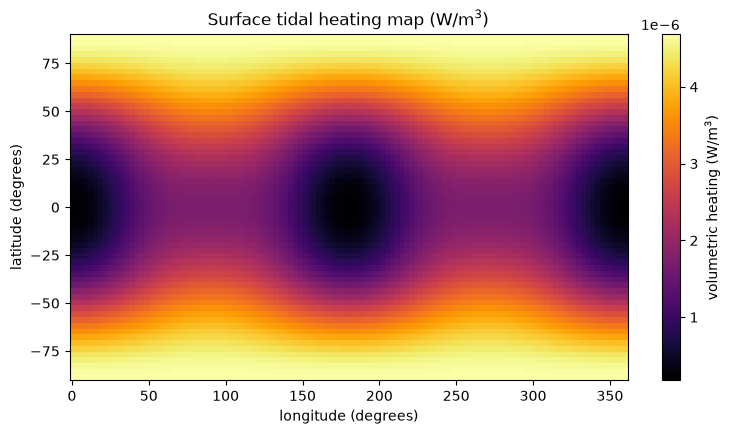

In [3]:
grid_colats = np.linspace(0.02, np.pi - 0.02, 60)
grid_lons = np.linspace(0.0, 2.0 * np.pi, 120)
result = io.calc_3d_tides(*ORBIT, radii=np.array([0.99 * R]),
                          colatitudes=grid_colats, longitudes=grid_lons)
heat_map = np.asarray(result["heating"])[0]      # (colatitude, longitude)

fig, ax = plt.subplots(figsize=(9, 4.5))
mesh = ax.pcolormesh(np.degrees(grid_lons), 90.0 - np.degrees(grid_colats), heat_map, cmap="inferno", shading="auto")
ax.set_xlabel("longitude (degrees)")
ax.set_ylabel("latitude (degrees)")
ax.set_title("Surface tidal heating map (W/m$^3$)")
fig.colorbar(mesh, ax=ax, label="volumetric heating (W/m$^3$)")
plt.show()


## Heating with Depth

In this homogeneous body the polar heating density is largest near the center and about 7.5 times smaller just below the surface. Shells farther out hold more volume, so the power per unit radius peaks near 0.63 of the radius, and the outer quarter of the radius supplies about a quarter of the total. The plot below is the polar profile from center to surface.

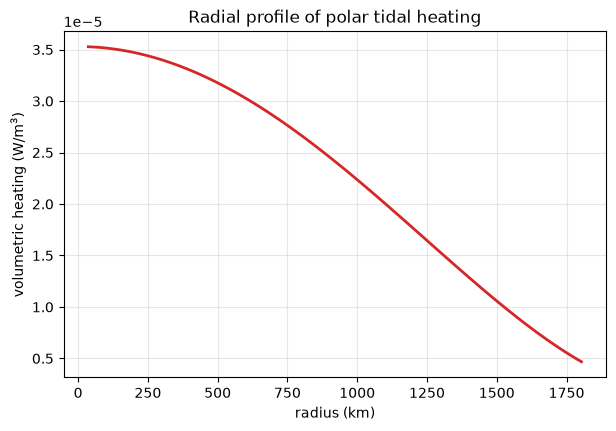

In [4]:
radii = np.linspace(0.02 * R, 0.99 * R, 120)
# One call for the whole profile, near the north pole
h_radial = io.get_3d_tidal_heating_array(*ORBIT, radii, np.full(radii.size, 0.05))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(radii / 1.0e3, h_radial, lw=2, color="tab:red")
ax.set_xlabel("radius (km)")
ax.set_ylabel("volumetric heating (W/m$^3$)")
ax.set_title("Radial profile of polar tidal heating")
ax.grid(alpha=0.3)
plt.show()


## Consistency with the Total

Integrating the 3D field over the volume reproduces the single total heating from `calc_tides`, to within the resolution of the integration grid. `calc_3d_tides` performs that integral with its summed arguments. With the default of 16 radial nodes per layer the two agree to about 4 parts per million here, and `radial_slices=64` gives the same difference, so the radial quadrature has already converged.


In [5]:
io.calc_tides(*ORBIT)
total_1d = io.get_tidal_heating()

summed = io.calc_3d_tides(*ORBIT, latitude_summed=True, longitude_summed=True, radial_summed=True)
total_3d = float(np.asarray(summed["total"]))

print(f"total from calc_tides       : {total_1d:.4e} W")
print(f"volume integral of 3D field : {total_3d:.4e} W")


total from calc_tides       : 2.6489e+14 W
volume integral of 3D field : 2.6489e+14 W


## Recap

- The same radial solution that gives Love numbers also gives the full 3D tidal strain and heating.
- `get_3d_tidal_heating(..., radius, colatitude)` returns the secular volumetric heating at a point, and `get_3d_tidal_heating_array(..., radii, colatitudes)` returns it at many points with one radial solve.
- `calc_3d_tides(..., radii=, colatitudes=, longitudes=)` returns it on a grid, or summed to a total.
- For this synchronous eccentric orbit the heating is strongest toward the poles, weakest on the equator at the sub-host and anti-host meridians, and densest at the center. The volume integral matches the single total from `calc_tides`.

Next: `10_thermal_eos` looks at how the equation of state and temperature shape the interior.
